# S&P 500 Market Predictor

**Created by**: Eric Liu, Rithikesh Muddana



## Imports

In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve, classification_report, confusion_matrix)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cpu


# DATA LOADING AND FEATURE ENGINEERING

In this section, all data files are merged together into one DataFrame. Luckily, all the data except for unemployment_rate followed the same date pattern (weekdays only) and were not missing any data points, so it was relatively simple to merge the data. Unemployment date was measured by month, however, so we filled in the daily unemployment rates by taking the most recent monthly value and applying it to all days in that month. Outliers were capped using winsorsizing, essnentially a technique that caps outliers at a specific percentile. Financial outliers are genuinely informative, so it doesn't make sense to outright discard them.

As for feature engineering, we use the existing data to extrapolate new features to use in training. The features are listed and explained below:

### Returns + Lags

`Return_1d / 3d / 5d / 10d / 20d`

Percentage change in closing price over the last 1, 3, 5, 10, and 20 days. These capture short and medium-term momentum — the idea being that recent price direction may persist or change

`Lag_1 through Lag_5`

Yesterday's return, the day before's return, and so on up to 5 days back. These give the model a "memory" of recent daily moves as individual inputs rather than just a rolling sum.

`Vol_5d`

Standard deviation of daily returns over the last 5 days. Measures how choppy the market has been recently.

### Volatility

`Vol_20d`

Same but over 20 days — a smoother, more stable estimate.

`Vol_ratio`

Vol_5d / Vol_20d. When this is above 1, short-term volatility is elevated relative to the recent norm — often signals turbulence from an event.

### Moving Averages & Crossovers

`Close_vs_SMA5/10/20/50/200`

How far the current price sits above or below each moving average, expressed as a percentage. A positive value means price is above the average (bullish), negative means below (bearish). The 200-day in particular is widely watched by institutional traders.

`SMA5_vs_SMA20`

Short-term average relative to medium-term. When the fast MA crosses above the slow MA, it's a classic "golden cross" — a bullish signal.

`SMA20_vs_SMA50`

Medium-term vs intermediate-term trend alignment.

`SMA50_vs_SMA200`

The big-picture trend. When the 50-day is above the 200-day, the market is `nerally in a long-term uptrend.

### RSI

`RSI_14`

Relative Strength Index over 14 days. Ranges from 0 to 100. Above 70 is traditionally "overbought" (potential reversal down), below 30 is "oversold" (potential bounce). It measures the speed and magnitude of recent price moves.

### MACD

`MACD`

The difference between the 12-day and 26-day exponential moving averages. Positive means the short-term trend is stronger than the long-term trend.

`MACD_signal`

A 9-day EMA smoothing of the MACD line itself — acts as a trigger line.

`MACD_hist MACD - MACD_signal.`

When positive and growing, momentum is accelerating upward. When it crosses zero, it's a buy/sell signal in classic technical analysis.

### Bollinger Bands

`BB_pct`

Where the current price sits within the Bollinger Band, from 0 (at the lower band) to 1 (at the upper band). Above 1 or below 0 means the price has broken out of the bands entirely.

`BB_width`

How wide the bands are relative to the moving average — a measure of volatility. Narrow bands (low width) often precede large moves.

In [2]:
import glob
import os
import pandas as pd

DATA_DIR = 'data'

def load_data() -> pd.DataFrame:

    # --- Load S&P 500 data (index_val files) ---
    index_val_files = glob.glob(os.path.join(DATA_DIR, 'index_val*.csv'))

    all_dfs = []

    for file in index_val_files:
        df = pd.read_csv(file)
        all_dfs.append(df)

    # Concatenate all dataframes into one
    combined_df = pd.concat(all_dfs, ignore_index=True)

    # Convert the 'Date' column to datetime
    combined_df['Date'] = pd.to_datetime(combined_df['Date'])

    # Convert OHLC columns to numeric
    price_cols = ['Open', 'High', 'Low', 'Close']
    combined_df[price_cols] = (
        combined_df[price_cols]
        .apply(lambda col: col.astype(str).str.replace(r'[\$,\s]', '', regex=True))
        .apply(pd.to_numeric, errors='coerce')
    )

    # Helper to standardize date column (because in some datasets, data is called observation_date, or date)
    def _standardize_date_column(df: pd.DataFrame, file_name: str) -> pd.DataFrame:
        date_col = None
        for col in df.columns:
            if col.lower() == 'date':
                date_col = col
                break
            if col.lower() == 'observation_date':
                date_col = col
                break

        if date_col:
            if date_col != 'Date':
                df = df.rename(columns={date_col: 'Date'})
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
            return df
        else:
            print(f"Warning: '{file_name}' does not contain a 'date' or 'observation_date' column. Skipping this file.")
            return None # Return None if date column not found

    # --- treasury_yield.csv ---
    treasury_df = pd.read_csv(os.path.join(DATA_DIR, 'treasury_yield.csv'))
    treasury_df = _standardize_date_column(treasury_df, 'treasury_yield.csv')

    yield_cols = [col for col in treasury_df.columns if col.lower() != 'date']
    treasury_df = treasury_df[['Date', yield_cols[0]]]
    treasury_df = treasury_df.rename(columns={yield_cols[0]: 'Treasury_Yield'})
    treasury_df['Treasury_Yield'] = pd.to_numeric(
        treasury_df['Treasury_Yield'].astype(str).str.replace(r'[\%,]', '', regex=True),
        errors='coerce'
    )
    combined_df = pd.merge(combined_df, treasury_df, on='Date', how='left')


    # --- unemployment_rate.csv ---
    unemployment_df = pd.read_csv(os.path.join(DATA_DIR, 'unemployment_rate.csv'))
    unemployment_df = _standardize_date_column(unemployment_df, 'unemployment_rate.csv')

    unemp_cols = [col for col in unemployment_df.columns if col.lower() != 'date']
    unemployment_df = unemployment_df[['Date', unemp_cols[0]]]
    unemployment_df = unemployment_df.rename(columns={unemp_cols[0]: 'Unemployment_Rate'})
    unemployment_df['Unemployment_Rate'] = pd.to_numeric(
        unemployment_df['Unemployment_Rate'].astype(str).str.replace(r'[\%,]', '', regex=True),
        errors='coerce'
    )
    combined_df = pd.merge(combined_df, unemployment_df, on='Date', how='left')


    # --- vix.csv ---
    vix_df = pd.read_csv(os.path.join(DATA_DIR, 'vix.csv'))
    vix_df = _standardize_date_column(vix_df, 'vix.csv')

    vix_df = vix_df[['Date', 'VIXCLS']].rename(columns={'VIXCLS': 'VIX_Close'})
    vix_df['VIX_Close'] = pd.to_numeric(
        vix_df['VIX_Close'].astype(str).str.replace(r'[\$,\s]', '', regex=True),
        errors='coerce'
    )
    combined_df = pd.merge(combined_df, vix_df, on='Date', how='left')

    # --- Apply cutoff date, sort by date ---
    combined_df = combined_df[combined_df['Date'] < '2026-01-01'].reset_index(drop=True)
    combined_df = combined_df.sort_values(by='Date').reset_index(drop=True)

    return combined_df

def data_cleaning(df):
    # Work on a copy — avoid mutating the original df
    df = df.copy()

    # Unemployment rate is monthly, forward-fill across trading days
    df['Unemployment_Rate'] = df['Unemployment_Rate'].ffill().bfill()

    # Treasury yield has 7 missing values — forward-fill then back-fill
    df['Treasury_Yield'] = df['Treasury_Yield'].ffill().bfill()

    # Winsorize all feature columns at 1st/99th percentile (winsorize is essentially making outliers capped to a specific percentile)
    feature_cols = [col for col in df.columns if col.lower() != 'date']
    for col in feature_cols:
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        df[col] = df[col].clip(lower, upper)

    return df

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()

    # --- Target: 1 if next day closes higher, else 0 ---
    d["Target"] = (d["Close"].shift(-1) > d["Close"]).astype(int)

     # --- Returns & lags ---
    d["Return_1d"]  = d["Close"].pct_change(1)
    d["Return_3d"]  = d["Close"].pct_change(3)
    d["Return_5d"]  = d["Close"].pct_change(5)
    d["Return_10d"] = d["Close"].pct_change(10)
    d["Return_20d"] = d["Close"].pct_change(20)

    for lag in [1, 2, 3, 4, 5]:
        d[f"Lag_{lag}"] = d["Return_1d"].shift(lag)

    # --- Volatility ---
    d["Vol_5d"]  = d["Return_1d"].rolling(5).std()
    d["Vol_20d"] = d["Return_1d"].rolling(20).std()
    d["Vol_ratio"] = d["Vol_5d"] / d["Vol_20d"]

    # --- Moving averages & crossovers ---
    for w in [5, 10, 20, 50, 200]:
        d[f"SMA_{w}"]       = d["Close"].rolling(w).mean()
        d[f"Close_vs_SMA{w}"] = d["Close"] / d[f"SMA_{w}"] - 1

    d["SMA5_vs_SMA20"]  = d["SMA_5"]  / d["SMA_20"]  - 1
    d["SMA20_vs_SMA50"] = d["SMA_20"] / d["SMA_50"]  - 1
    d["SMA50_vs_SMA200"] = d["SMA_50"] / d["SMA_200"] - 1

    # --- RSI ---
    delta = d["Close"].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / loss.replace(0, np.nan)
    d["RSI_14"] = 100 - (100 / (1 + rs))

    # --- MACD ---
    ema12 = d["Close"].ewm(span=12, adjust=False).mean()
    ema26 = d["Close"].ewm(span=26, adjust=False).mean()
    d["MACD"]        = ema12 - ema26
    d["MACD_signal"] = d["MACD"].ewm(span=9, adjust=False).mean()
    d["MACD_hist"]   = d["MACD"] - d["MACD_signal"]

    # --- Bollinger Bands ---
    sma20  = d["Close"].rolling(20).mean()
    std20  = d["Close"].rolling(20).std()
    d["BB_upper"] = sma20 + 2 * std20
    d["BB_lower"] = sma20 - 2 * std20
    d["BB_pct"]   = (d["Close"] - d["BB_lower"]) / (d["BB_upper"] - d["BB_lower"])
    d["BB_width"] = (d["BB_upper"] - d["BB_lower"]) / sma20

    # --- Intraday range features ---
    d["High_Low_range"]  = (d["High"] - d["Low"]) / d["Close"]
    d["Open_Close_gap"]  = (d["Open"] - d["Close"].shift(1)) / d["Close"].shift(1)

    return d

df = load_data()
df = build_features(df)
df = data_cleaning(df)

display(df.head())
display(df.info())
display(df.describe())

print("Dataset:", df.shape)


,Date,Open,High,Low,Close,Treasury_Yield,Unemployment_Rate,VIX_Close,Target,Return_1d,...,RSI_14,MACD,MACD_signal,MACD_hist,BB_upper,BB_lower,BB_pct,BB_width,High_Low_range,Open_Close_gap
0,2022-01-18,4632.24,4632.24,4568.70,4577.11,1.87,3.9,22.79,0,NaN,...,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.013882,NaN
1,2022-01-19,4588.03,4611.55,4530.20,4532.76,1.83,3.9,23.85,0,-0.009690,...,NaN,-3.537892,-0.707578,-2.830313,NaN,NaN,NaN,NaN,0.017947,0.002386
2,2022-01-20,4547.35,4602.11,4477.95,4482.73,1.83,3.9,25.59,0,-0.011037,...,NaN,-10.260424,-2.618147,-7.642276,NaN,NaN,NaN,NaN,0.027697,0.003219
3,2022-01-21,4471.38,4494.52,4395.34,4397.94,1.81,3.9,28.85,1,-0.018915,...,NaN,-22.174311,-6.529380,-15.644931,NaN,NaN,NaN,NaN,0.022551,-0.002532
4,2022-01-24,4356.32,4417.35,4222.62,4410.13,1.81,3.9,29.90,0,0.002772,...,NaN,-30.283433,-11.280191,-19.003242,NaN,NaN,NaN,NaN,0.036918,-0.009464


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               993 non-null    datetime64[ns]
 1   Open               993 non-null    float64       
 2   High               993 non-null    float64       
 3   Low                993 non-null    float64       
 4   Close              993 non-null    float64       
 5   Treasury_Yield     993 non-null    float64       
 6   Unemployment_Rate  993 non-null    float64       
 7   VIX_Close          993 non-null    float64       
 8   Target             993 non-null    int64         
 9   Return_1d          992 non-null    float64       
 10  Return_3d          990 non-null    float64       
 11  Return_5d          988 non-null    float64       
 12  Return_10d         983 non-null    float64       
 13  Return_20d         973 non-null    float64       
 14  Lag_1     

None

,Date,Open,High,Low,Close,Treasury_Yield,Unemployment_Rate,VIX_Close,Target,Return_1d,...,RSI_14,MACD,MACD_signal,MACD_hist,BB_upper,BB_lower,BB_pct,BB_width,High_Low_range,Open_Close_gap
count,993,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,992.000000,...,979.000000,993.000000,993.000000,993.000000,974.000000,974.000000,974.000000,974.000000,993.000000,992.000000
mean,2024-01-08 16:49:18.308157184,5009.362790,5037.661313,4978.664878,5009.970224,3.876113,3.893958,19.208848,0.531722,0.000425,...,55.885224,15.877312,15.741150,0.136569,5166.030087,4827.871823,0.596328,0.069829,0.012064,0.000249
min,2022-01-18 00:00:00,3681.374400,3711.656800,3635.783600,3666.690800,1.810000,3.500000,12.217600,0.000000,-0.032080,...,21.295785,-118.682116,-113.653810,-38.594180,3900.269977,3522.724661,-0.104457,0.027072,0.003082,-0.015861
25%,2023-01-12 00:00:00,4155.710000,4177.510000,4127.180000,4155.170000,3.610000,3.600000,14.910000,0.000000,-0.005026,...,42.637582,-17.997750,-16.011613,-9.706224,4325.646507,4050.235223,0.358504,0.044739,0.007003,-0.002181
50%,2024-01-09 00:00:00,4764.730000,4785.390000,4747.120000,4774.750000,4.090000,3.900000,17.800000,1.000000,0.000693,...,57.477057,29.228684,26.698028,0.292100,4869.195893,4679.002605,0.683044,0.061492,0.010273,0.000443
75%,2025-01-03 00:00:00,5817.800000,5846.520000,5786.080000,5815.260000,4.310000,4.200000,22.290000,1.000000,0.006300,...,67.978102,55.925250,53.217859,9.880968,6032.814640,5646.875657,0.849288,0.085378,0.014958,0.002908
max,2025-12-31 00:00:00,6875.517600,6899.915600,6843.988800,6875.426400,4.830000,4.400000,33.836000,1.000000,0.025983,...,88.815753,96.496614,91.555704,44.139596,6967.048518,6655.275063,1.080474,0.177469,0.036918,0.014222
std,NaN,934.997524,934.234596,935.075930,934.938520,0.660657,0.300342,5.418499,0.499244,0.010346,...,16.044455,50.488397,47.593983,15.932419,920.720123,925.430733,0.317246,0.033625,0.007012,0.004815


Dataset: (993, 45)


## Data Alignment Rules

Here's how we merge data sources that come at different frequencies:

- **Date range**: ~Jan 2022 through Dec 2025 (roughly 993 trading days)
- **S&P 500 (daily)**: This is our primary time axis — everything else gets joined onto these dates
- **VIX (daily)**: Also daily from FRED, merges directly on date
- **10-Year Treasury Yield (daily)**: Daily from FRED, has a handful of gaps on holidays — forward-filled
- **Unemployment Rate (monthly)**: Released once a month by BLS. We forward-fill so each trading day uses the most recently released figure. This avoids look-ahead since BLS releases with ~1 month lag anyway.

**Prediction horizon**: Next-day close-to-close. On day *t* we predict whether day *t+1*'s close will be higher than day *t*'s close.

**Feature leakage prevention**: All engineered features (rolling averages, RSI, MACD, etc.) are computed using only data available at time *t*. The target uses `shift(-1)` so it looks one day ahead, but no feature ever peeks into the future.

# Exploratory Data Analysis

Let's look at the data before we throw models at it.

Up days: 528 (53.2%)
Down days: 465 (46.8%)


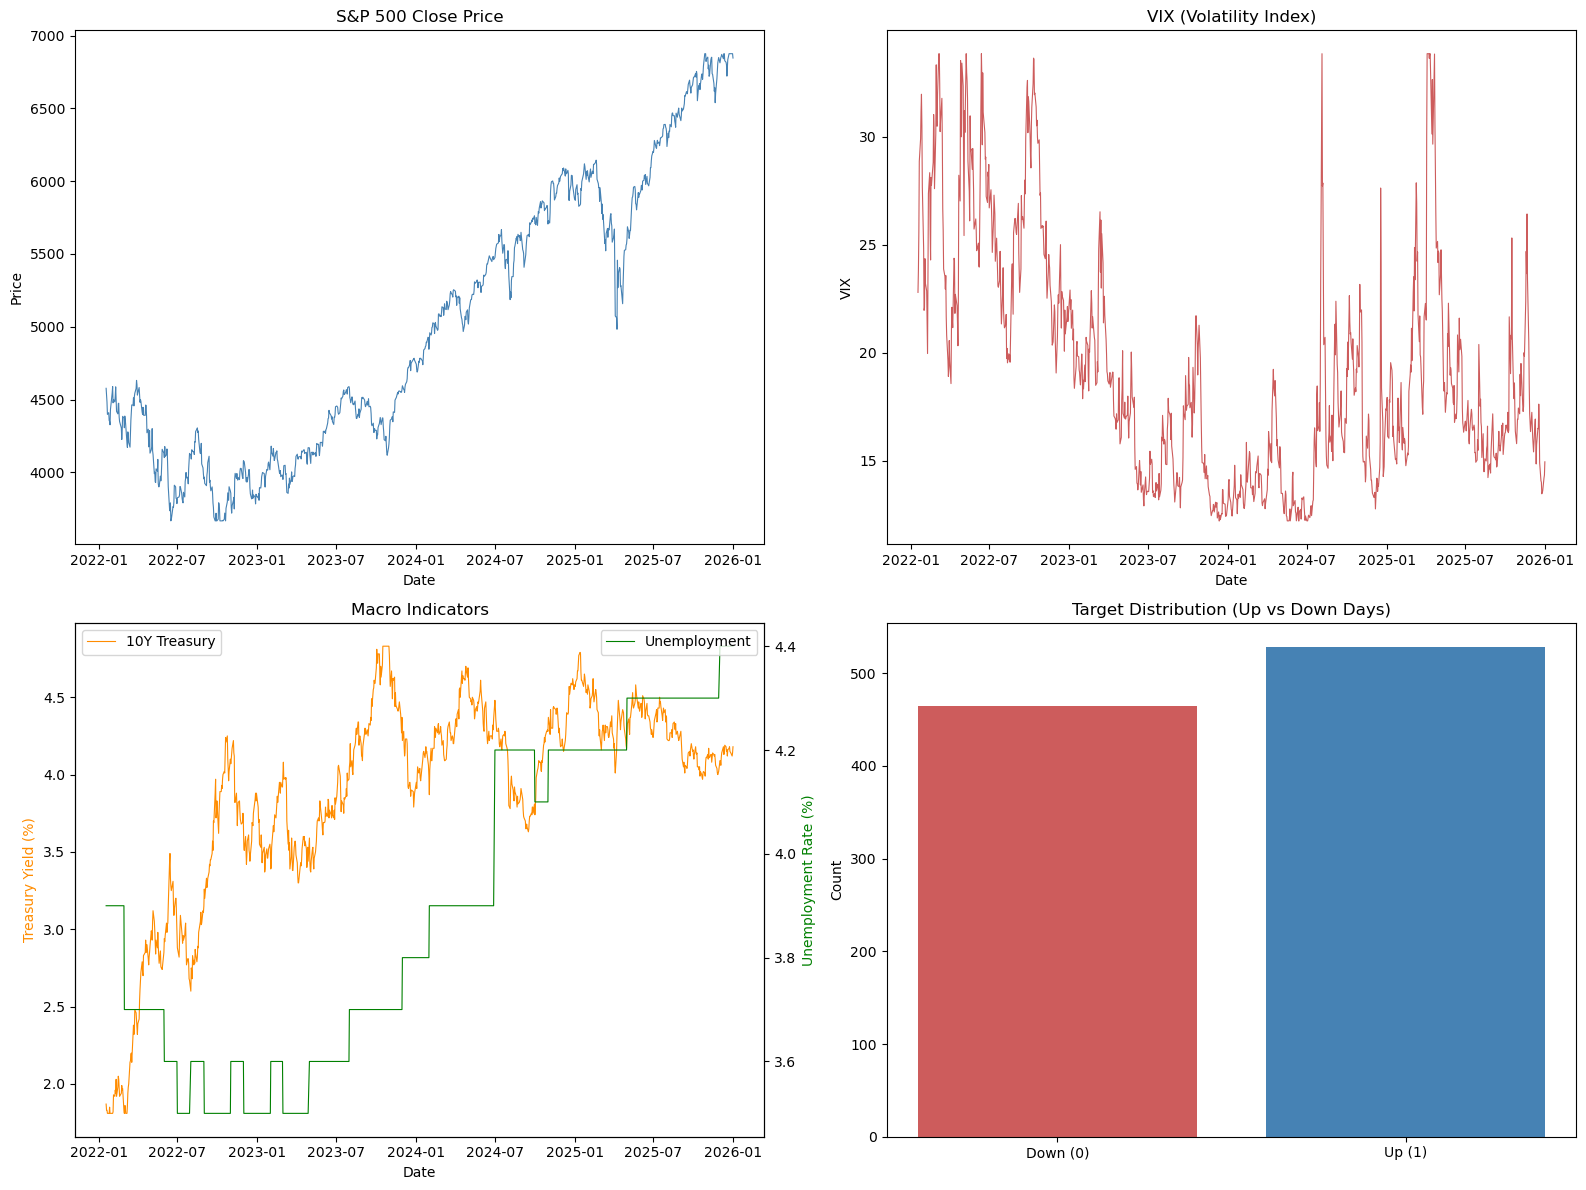

In [3]:
# -- class balance --
up_days = df['Target'].sum()
down_days = len(df) - up_days
print(f"Up days: {up_days} ({up_days/len(df)*100:.1f}%)")
print(f"Down days: {down_days} ({down_days/len(df)*100:.1f}%)")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# S&P 500 closing price over time
axes[0, 0].plot(df['Date'], df['Close'], color='steelblue', linewidth=0.8)
axes[0, 0].set_title('S&P 500 Close Price')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price')

# VIX over time
axes[0, 1].plot(df['Date'], df['VIX_Close'], color='indianred', linewidth=0.8)
axes[0, 1].set_title('VIX (Volatility Index)')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('VIX')

# treasury yield + unemployment on same plot
ax3 = axes[1, 0]
ax3.plot(df['Date'], df['Treasury_Yield'], color='darkorange', linewidth=0.8, label='10Y Treasury')
ax3.set_ylabel('Treasury Yield (%)', color='darkorange')
ax3_twin = ax3.twinx()
ax3_twin.plot(df['Date'], df['Unemployment_Rate'], color='green', linewidth=0.8, label='Unemployment')
ax3_twin.set_ylabel('Unemployment Rate (%)', color='green')
ax3.set_title('Macro Indicators')
ax3.set_xlabel('Date')
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')

# target distribution
axes[1, 1].bar(['Down (0)', 'Up (1)'], [down_days, up_days], color=['indianred', 'steelblue'])
axes[1, 1].set_title('Target Distribution (Up vs Down Days)')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

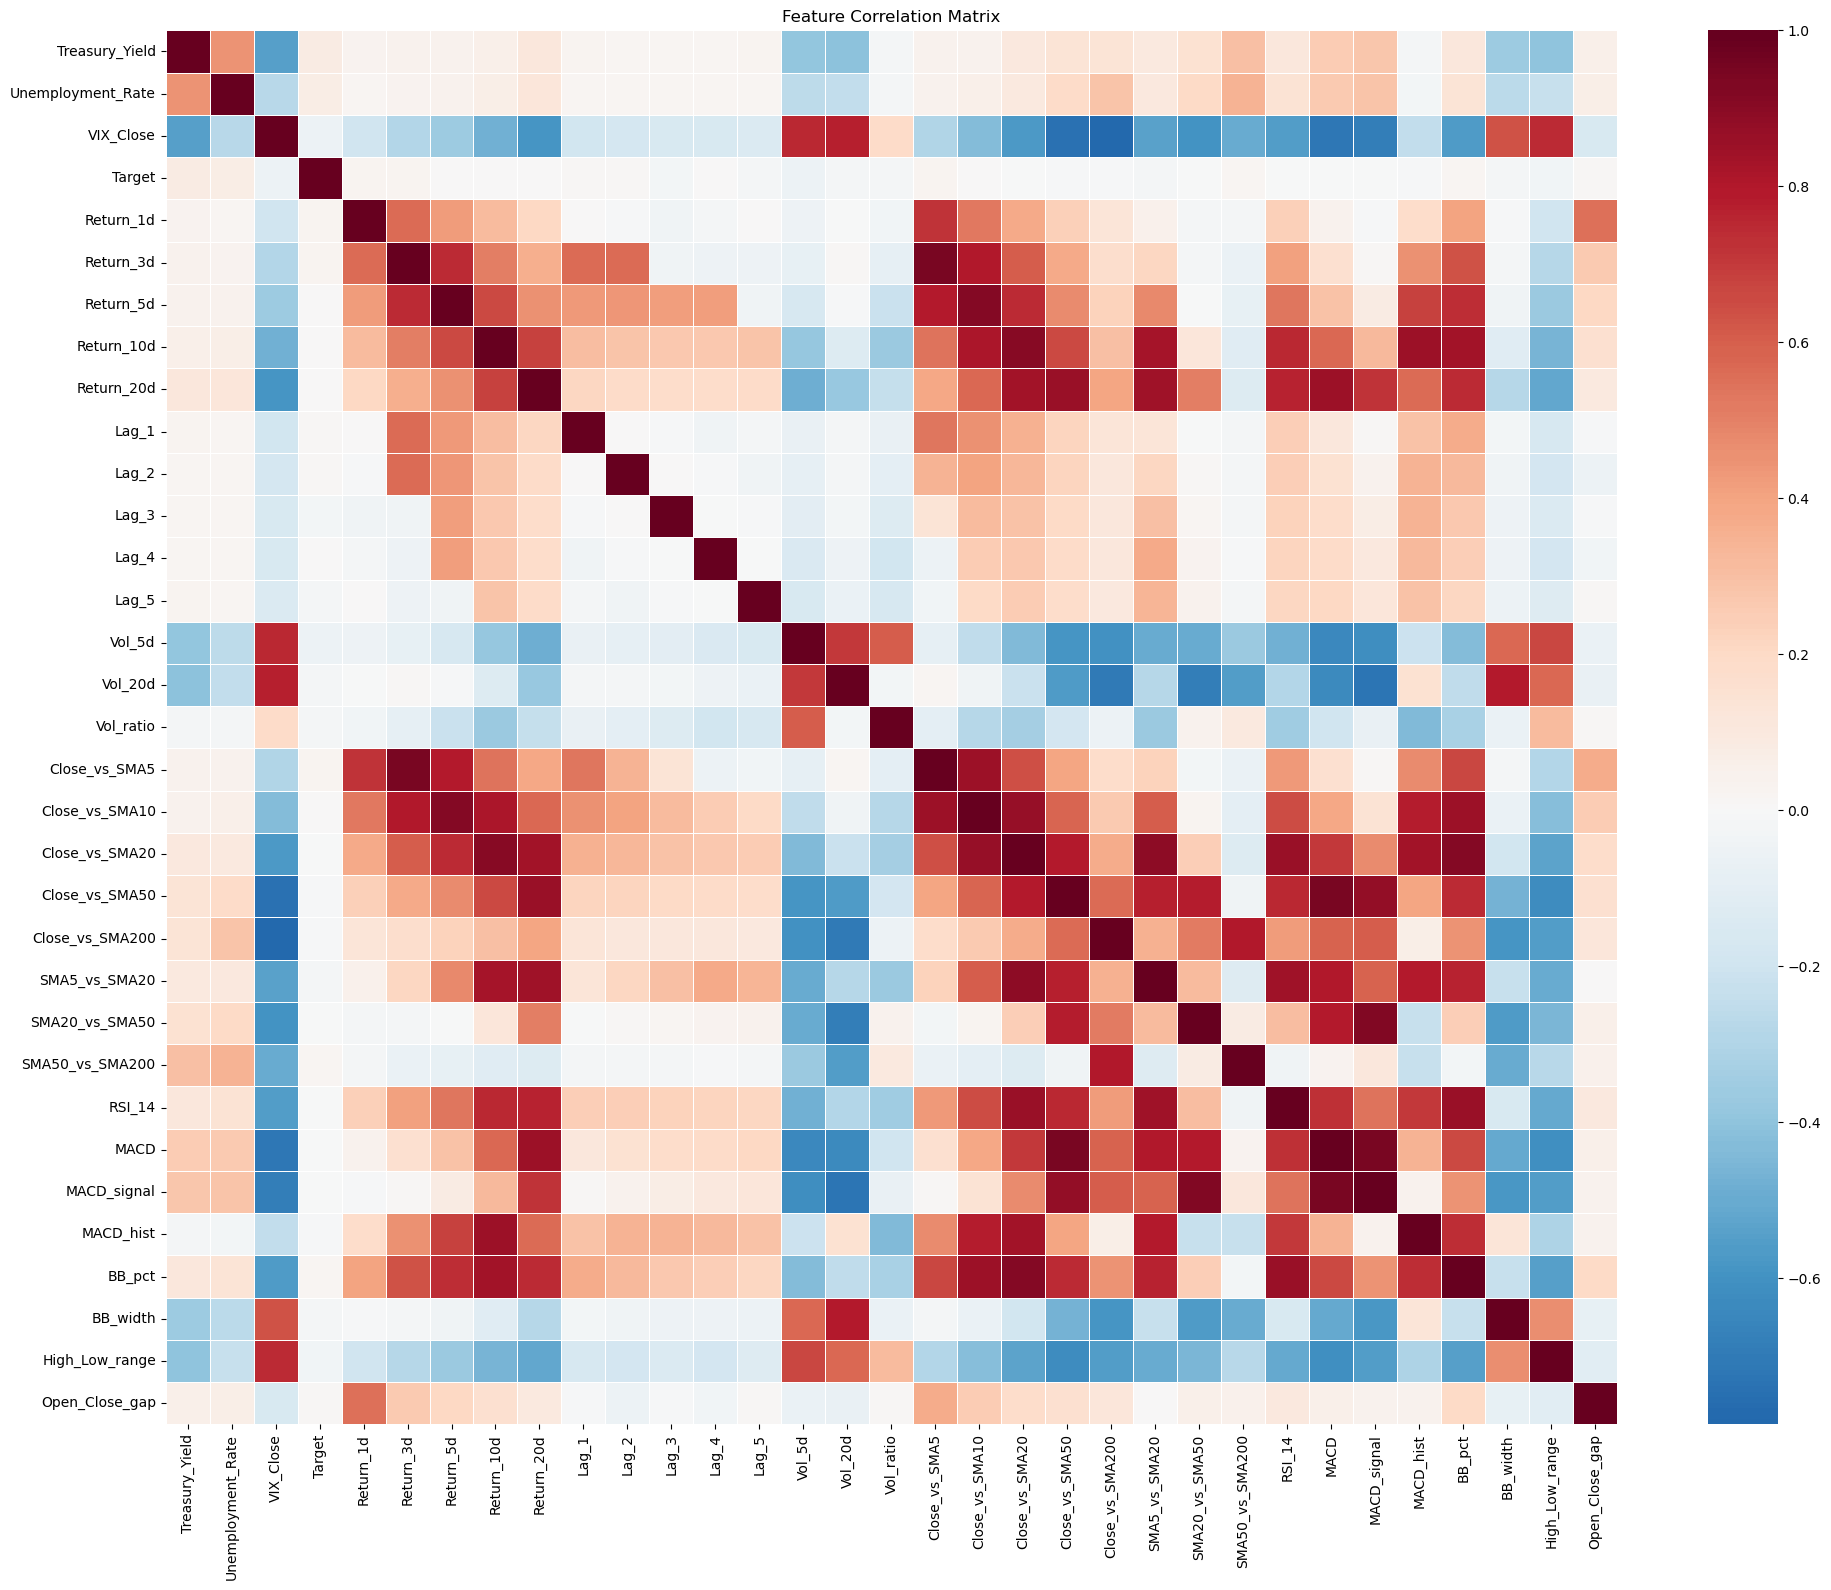

Top 10 positively correlated with Target:
Treasury_Yield       0.080114
Unemployment_Rate    0.075232
Return_3d            0.029402
Close_vs_SMA5        0.026066
Return_1d            0.024727
SMA50_vs_SMA200      0.019004
BB_pct               0.016296
Lag_1                0.015372
Open_Close_gap       0.011882
Lag_2                0.010992
Name: Target, dtype: float64

Top 10 negatively correlated with Target:
MACD_hist        -0.010791
SMA5_vs_SMA20    -0.015648
Lag_5            -0.015780
BB_width         -0.022303
Vol_ratio        -0.025457
Vol_20d          -0.025663
Lag_3            -0.029513
High_Low_range   -0.039308
Vol_5d           -0.054479
VIX_Close        -0.055779
Name: Target, dtype: float64


In [4]:
# correlation heatmap — only for features we'll actually train on
# dropping raw price columns and intermediate SMA values since those are just used to derive ratios
drop_for_corr = ['Date', 'Open', 'High', 'Low', 'Close',
                 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'SMA_200',
                 'BB_upper', 'BB_lower']
corr_df = df.drop(columns=[c for c in drop_for_corr if c in df.columns])
corr_matrix = corr_df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0,
            linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# see what correlates most with our target
target_corr = corr_matrix['Target'].drop('Target').sort_values(ascending=False)
print("Top 10 positively correlated with Target:")
print(target_corr.head(10))
print("\nTop 10 negatively correlated with Target:")
print(target_corr.tail(10))

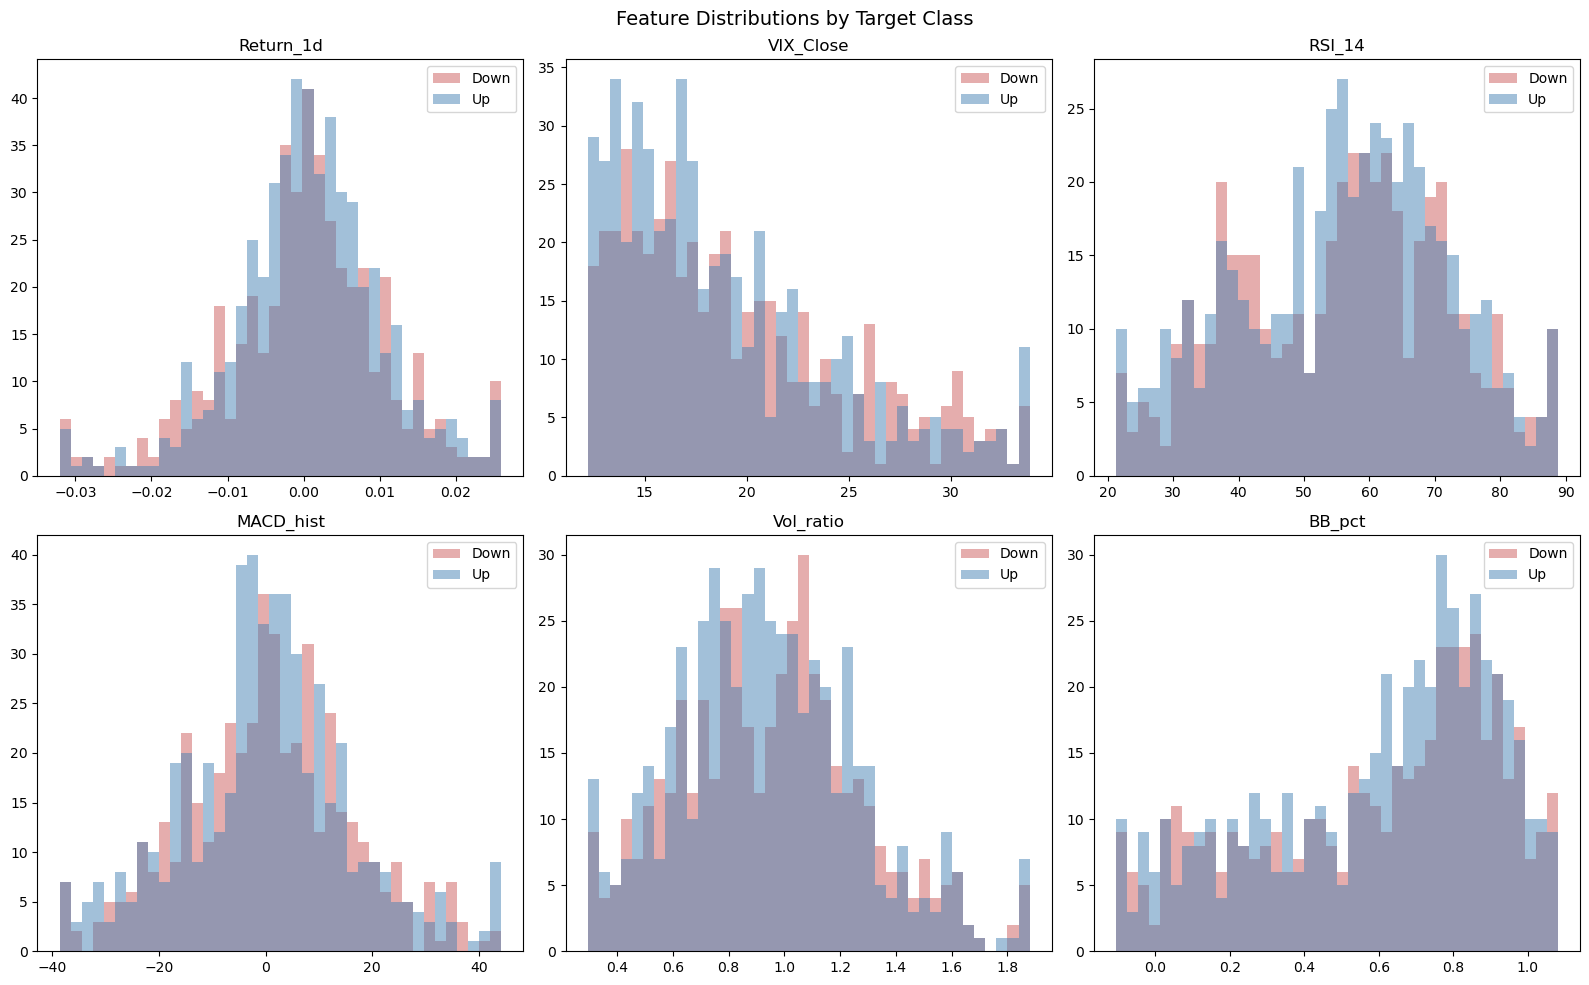

In [5]:
# distribution of a few key features, split by up/down days
key_features = ['Return_1d', 'VIX_Close', 'RSI_14', 'MACD_hist', 'Vol_ratio', 'BB_pct']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for label, color in [(0, 'indianred'), (1, 'steelblue')]:
        subset = df[df['Target'] == label][feat].dropna()
        axes[i].hist(subset, bins=40, alpha=0.5, color=color,
                     label=f'{"Up" if label else "Down"}')
    axes[i].set_title(feat)
    axes[i].legend()

plt.suptitle('Feature Distributions by Target Class', fontsize=14)
plt.tight_layout()
plt.show()

# Data Splitting & Preprocessing

We split **chronologically** — no random shuffling. Market data is time-dependent, so randomly mixing future and past data would be unrealistic and leak information.

- **Train**: everything before July 2024
- **Validation**: July 2024 through December 2024
- **Test**: January 2025 onwards

We also have to drop the first ~200 rows since they have NaN from the 200-day SMA warmup period. After that, we scale features with RobustScaler (more resilient to the remaining outliers than StandardScaler).

In [6]:
# columns that shouldn't be used as model inputs
drop_cols = ['Date', 'Open', 'High', 'Low', 'Close',
             'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'SMA_200',
             'BB_upper', 'BB_lower', 'Target']

feature_cols = [c for c in df.columns if c not in drop_cols]

# kill the NaN rows from rolling window warmup
model_df = df.dropna(subset=feature_cols).copy()
model_df = model_df.reset_index(drop=True)
print(f"After dropping NaN warmup rows: {len(model_df)} samples (lost {len(df) - len(model_df)} rows)")

# chronological split
train_mask = model_df['Date'] < '2024-07-01'
val_mask   = (model_df['Date'] >= '2024-07-01') & (model_df['Date'] < '2025-01-01')
test_mask  = model_df['Date'] >= '2025-01-01'

X_train = model_df.loc[train_mask, feature_cols].values
y_train = model_df.loc[train_mask, 'Target'].values
X_val   = model_df.loc[val_mask, feature_cols].values
y_val   = model_df.loc[val_mask, 'Target'].values
X_test  = model_df.loc[test_mask, feature_cols].values
y_test  = model_df.loc[test_mask, 'Target'].values

# hang onto dates for plotting later
dates_train = model_df.loc[train_mask, 'Date'].values
dates_val   = model_df.loc[val_mask, 'Date'].values
dates_test  = model_df.loc[test_mask, 'Date'].values

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Train period: {model_df.loc[train_mask, 'Date'].min().date()} to {model_df.loc[train_mask, 'Date'].max().date()}")
print(f"Val period:   {model_df.loc[val_mask, 'Date'].min().date()} to {model_df.loc[val_mask, 'Date'].max().date()}")
print(f"Test period:  {model_df.loc[test_mask, 'Date'].min().date()} to {model_df.loc[test_mask, 'Date'].max().date()}")

# fit scaler on training data only — don't want test info leaking in
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"\nClass balance — Train: {y_train.mean():.3f} up | Val: {y_val.mean():.3f} up | Test: {y_test.mean():.3f} up")

After dropping NaN warmup rows: 794 samples (lost 199 rows)
Train: 416 | Val: 128 | Test: 250
Train period: 2022-11-01 to 2024-06-28
Val period:   2024-07-01 to 2024-12-31
Test period:  2025-01-02 to 2025-12-31

Class balance — Train: 0.538 up | Val: 0.570 up | Test: 0.576 up


## Baseline Models

Before any real ML, we need sanity-check baselines. If our models can't beat these, something's wrong.

1. **Always Up** — just predict 1 every time (markets tend to drift upward)
2. **Same as Yesterday** — predict today's direction = yesterday's direction
3. **Return-Only Logistic** — logistic regression using only yesterday's return as input

In [7]:
# quick helper so we don't copy-paste the same metrics code for every model
def evaluate_model(name, y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else None

    print(f"--- {name} ---")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    if auc is not None:
        print(f"  ROC-AUC:   {auc:.4f}")
    print(f"  Confusion Matrix:\n{confusion_matrix(y_true, y_pred)}\n")

    return {'name': name, 'accuracy': acc, 'f1': f1, 'precision': prec,
            'recall': rec, 'roc_auc': auc}

# store all results here — we'll make a comparison table at the end
results = []
prob_dict = {}  # name -> test probabilities, for ROC curves later

# --- baseline 1: always predict up ---
y_always_up = np.ones_like(y_test)
results.append(evaluate_model("Always Up", y_test, y_always_up))

# --- baseline 2: same direction as yesterday ---
# first test day uses last val day's actual direction as "yesterday"
y_yesterday = np.concatenate([[y_val[-1]], y_test[:-1]])
results.append(evaluate_model("Same as Yesterday", y_test, y_yesterday))

# --- baseline 3: logistic regression with only Return_1d ---
ret_idx = feature_cols.index('Return_1d')
X_train_ret = X_train_scaled[:, ret_idx].reshape(-1, 1)
X_test_ret  = X_test_scaled[:, ret_idx].reshape(-1, 1)

simple_lr = LogisticRegression(random_state=RANDOM_STATE)
simple_lr.fit(X_train_ret, y_train)
y_pred_simple = simple_lr.predict(X_test_ret)
y_prob_simple = simple_lr.predict_proba(X_test_ret)[:, 1]

results.append(evaluate_model("Return-Only Logistic", y_test, y_pred_simple, y_prob_simple))
prob_dict['Return-Only Logistic'] = y_prob_simple

--- Always Up ---
  Accuracy:  0.5760
  F1:        0.7310
  Precision: 0.5760
  Recall:    1.0000
  Confusion Matrix:
[[  0 106]
 [  0 144]]

--- Same as Yesterday ---
  Accuracy:  0.5040
  F1:        0.5694
  Precision: 0.5694
  Recall:    0.5694
  Confusion Matrix:
[[44 62]
 [62 82]]

--- Return-Only Logistic ---
  Accuracy:  0.5320
  F1:        0.6812
  Precision: 0.5605
  Recall:    0.8681
  ROC-AUC:   0.4892
  Confusion Matrix:
[[  8  98]
 [ 19 125]]



In [8]:
# logistic regression with full feature set — nice interpretable starting point
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr))
prob_dict['Logistic Regression'] = y_prob_lr

# which features does LR think matter?
coef_df = pd.DataFrame({'feature': feature_cols, 'coef': lr_model.coef_[0]})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index)
print("Top 10 features by |coefficient|:")
print(coef_df.head(10).to_string(index=False))

--- Logistic Regression ---
  Accuracy:  0.5720
  F1:        0.7206
  Precision: 0.5774
  Recall:    0.9583
  ROC-AUC:   0.4505
  Confusion Matrix:
[[  5 101]
 [  6 138]]

Top 10 features by |coefficient|:
          feature      coef
           BB_pct  0.756717
    SMA5_vs_SMA20 -0.691302
            Lag_1 -0.570854
        VIX_Close -0.524312
   Close_vs_SMA20 -0.488432
   Close_vs_SMA50 -0.484297
           Vol_5d -0.425371
       Return_10d  0.417109
   Treasury_Yield -0.407824
Unemployment_Rate  0.360497


### Random Forest

--- Random Forest ---
  Accuracy:  0.5240
  F1:        0.6246
  Precision: 0.5723
  Recall:    0.6875
  ROC-AUC:   0.4879
  Confusion Matrix:
[[32 74]
 [45 99]]



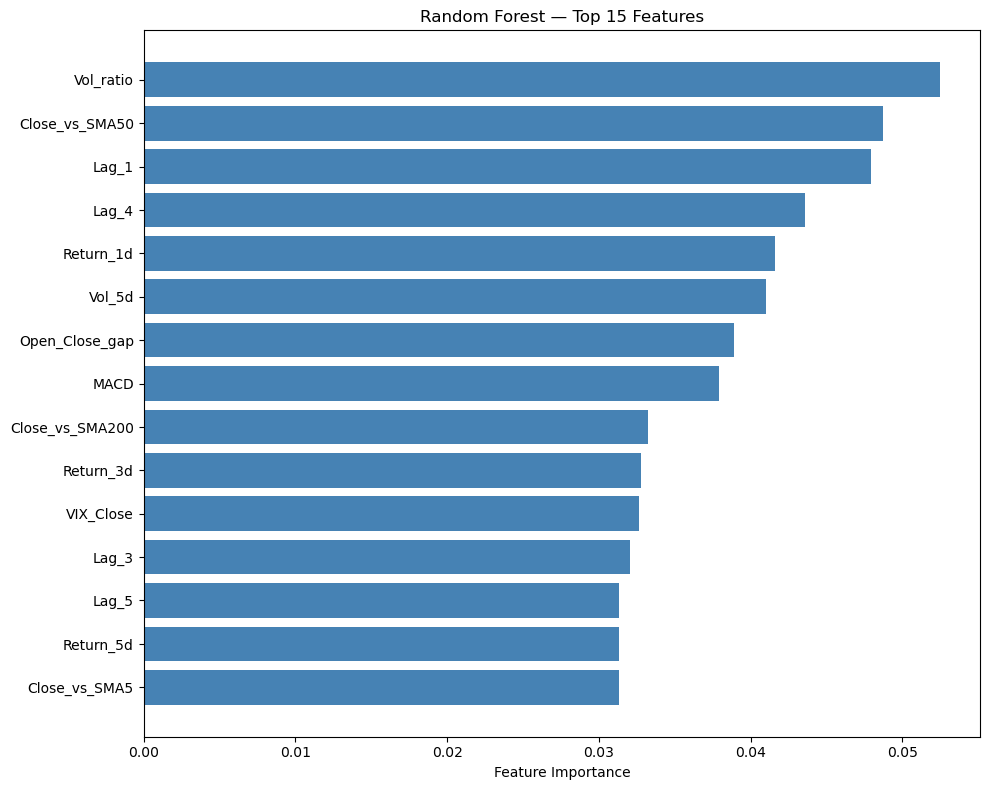

In [9]:
# random forest — good at capturing nonlinear interactions
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

results.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf))
prob_dict['Random Forest'] = y_prob_rf

# feature importance from the forest
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'][:15], importance_df['importance'][:15], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Random Forest — Top 15 Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Gradient Boosting

In [10]:
# gradient boosting — usually the strongest out-of-the-box for tabular data
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    min_samples_leaf=10,
    subsample=0.8,
    random_state=RANDOM_STATE
)
gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)
y_prob_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

results.append(evaluate_model("Gradient Boosting", y_test, y_pred_gb, y_prob_gb))
prob_dict['Gradient Boosting'] = y_prob_gb

--- Gradient Boosting ---
  Accuracy:  0.5480
  F1:        0.5979
  Precision: 0.6131
  Recall:    0.5833
  ROC-AUC:   0.5174
  Confusion Matrix:
[[53 53]
 [60 84]]



In [11]:
from itertools import product

# combine train + val for walk-forward tuning, then final eval on test
X_trainval = np.vstack([X_train_scaled, X_val_scaled])
y_trainval = np.concatenate([y_train, y_val])

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
}

# try a random subset of combos instead of full grid — faster and usually good enough
all_combos = list(product(param_grid['n_estimators'],
                          param_grid['max_depth'],
                          param_grid['learning_rate']))
rng = np.random.RandomState(RANDOM_STATE)
rng.shuffle(all_combos)
combos_to_try = all_combos[:12]

best_f1 = 0
best_params = {}
fold_results = []

for n_est, depth, lr in combos_to_try:
    fold_f1s = []
    for train_idx, val_idx in tscv.split(X_trainval):
        m = GradientBoostingClassifier(
            n_estimators=n_est, max_depth=depth, learning_rate=lr,
            min_samples_leaf=10, subsample=0.8, random_state=RANDOM_STATE
        )
        m.fit(X_trainval[train_idx], y_trainval[train_idx])
        preds = m.predict(X_trainval[val_idx])
        fold_f1s.append(f1_score(y_trainval[val_idx], preds))

    mean_f1 = np.mean(fold_f1s)
    std_f1  = np.std(fold_f1s)
    fold_results.append((n_est, depth, lr, mean_f1, std_f1))

    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_params = {'n_estimators': n_est, 'max_depth': depth, 'learning_rate': lr}

# show top 5 combos
fold_results.sort(key=lambda x: x[3], reverse=True)
print("Walk-forward CV results (top 5 by mean F1):")
for n_est, depth, lr, mf1, sf1 in fold_results[:5]:
    print(f"  n_est={n_est}, depth={depth}, lr={lr}  =>  F1 = {mf1:.4f} +/- {sf1:.4f}")

print(f"\nBest params: {best_params}")

# retrain on full train+val with best params, evaluate on test
gb_tuned = GradientBoostingClassifier(
    **best_params,
    min_samples_leaf=10, subsample=0.8, random_state=RANDOM_STATE
)
gb_tuned.fit(X_trainval, y_trainval)

y_pred_gb_tuned = gb_tuned.predict(X_test_scaled)
y_prob_gb_tuned = gb_tuned.predict_proba(X_test_scaled)[:, 1]

results.append(evaluate_model("Gradient Boosting (Tuned)", y_test, y_pred_gb_tuned, y_prob_gb_tuned))
prob_dict['Gradient Boosting (Tuned)'] = y_prob_gb_tuned

Walk-forward CV results (top 5 by mean F1):
  n_est=100, depth=3, lr=0.01  =>  F1 = 0.5676 +/- 0.1011
  n_est=200, depth=5, lr=0.05  =>  F1 = 0.5602 +/- 0.0615
  n_est=300, depth=5, lr=0.01  =>  F1 = 0.5538 +/- 0.0443
  n_est=100, depth=3, lr=0.05  =>  F1 = 0.5534 +/- 0.0541
  n_est=200, depth=3, lr=0.01  =>  F1 = 0.5469 +/- 0.0657

Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
--- Gradient Boosting (Tuned) ---
  Accuracy:  0.5240
  F1:        0.6293
  Precision: 0.5706
  Recall:    0.7014
  ROC-AUC:   0.4942
  Confusion Matrix:
[[ 30  76]
 [ 43 101]]



## Neural Network

Simple feedforward MLP — nothing too deep. With only ~800 samples the dataset is pretty small for neural nets, so we keep it modest and use dropout + early stopping to avoid overfitting.

Epoch 20: loss=0.6250, val_f1=0.6556
Early stopping at epoch 24
--- Neural Network (MLP) ---
  Accuracy:  0.5520
  F1:        0.7021
  Precision: 0.5690
  Recall:    0.9167
  ROC-AUC:   0.4486
  Confusion Matrix:
[[  6 100]
 [ 12 132]]



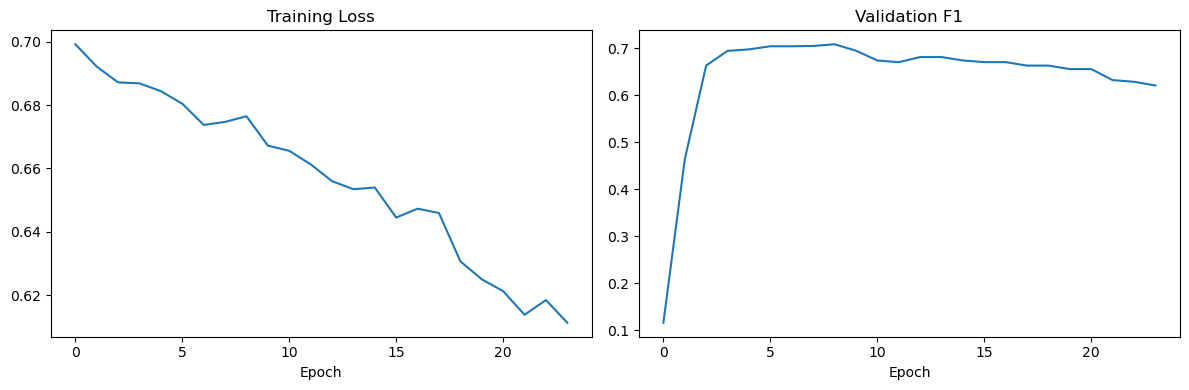

In [12]:
class MarketMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

# convert everything to tensors
X_train_t = torch.FloatTensor(X_train_scaled).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t   = torch.FloatTensor(X_val_scaled).to(device)
y_val_t   = torch.FloatTensor(y_val).to(device)
X_test_t  = torch.FloatTensor(X_test_scaled).to(device)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)  # no shuffle — time series

model_nn  = MarketMLP(X_train_scaled.shape[1]).to(device)
optimizer = torch.optim.Adam(model_nn.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCELoss()

# training with early stopping on val F1
n_epochs = 100
best_val_f1 = 0
patience_counter = 0
patience = 15
train_losses = []
val_f1_history = []
best_state = None

for epoch in range(n_epochs):
    model_nn.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model_nn(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    # check val performance
    model_nn.eval()
    with torch.no_grad():
        val_probs = model_nn(X_val_t).cpu().numpy()
        val_preds = (val_probs > 0.5).astype(int)
        vf1 = f1_score(y_val, val_preds)
        val_f1_history.append(vf1)

        if vf1 > best_val_f1:
            best_val_f1 = vf1
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model_nn.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: loss={train_losses[-1]:.4f}, val_f1={vf1:.4f}")

# load best checkpoint and get test predictions
model_nn.load_state_dict(best_state)
model_nn.eval()
with torch.no_grad():
    nn_test_probs = model_nn(X_test_t).cpu().numpy()
    nn_test_preds = (nn_test_probs > 0.5).astype(int)

results.append(evaluate_model("Neural Network (MLP)", y_test, nn_test_preds, nn_test_probs))
prob_dict['Neural Network (MLP)'] = nn_test_probs

# training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax2.plot(val_f1_history)
ax2.set_title('Validation F1')
ax2.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

# Model Comparison & Evaluation

Side-by-side comparison of everything we tried.

All models ranked by F1 score:

                     name accuracy     f1 precision recall roc_auc
                Always Up   0.5760 0.7310    0.5760 1.0000     nan
      Logistic Regression   0.5720 0.7206    0.5774 0.9583  0.4505
     Neural Network (MLP)   0.5520 0.7021    0.5690 0.9167  0.4486
     Return-Only Logistic   0.5320 0.6812    0.5605 0.8681  0.4892
Gradient Boosting (Tuned)   0.5240 0.6293    0.5706 0.7014  0.4942
            Random Forest   0.5240 0.6246    0.5723 0.6875  0.4879
        Gradient Boosting   0.5480 0.5979    0.6131 0.5833  0.5174
        Same as Yesterday   0.5040 0.5694    0.5694 0.5694     nan


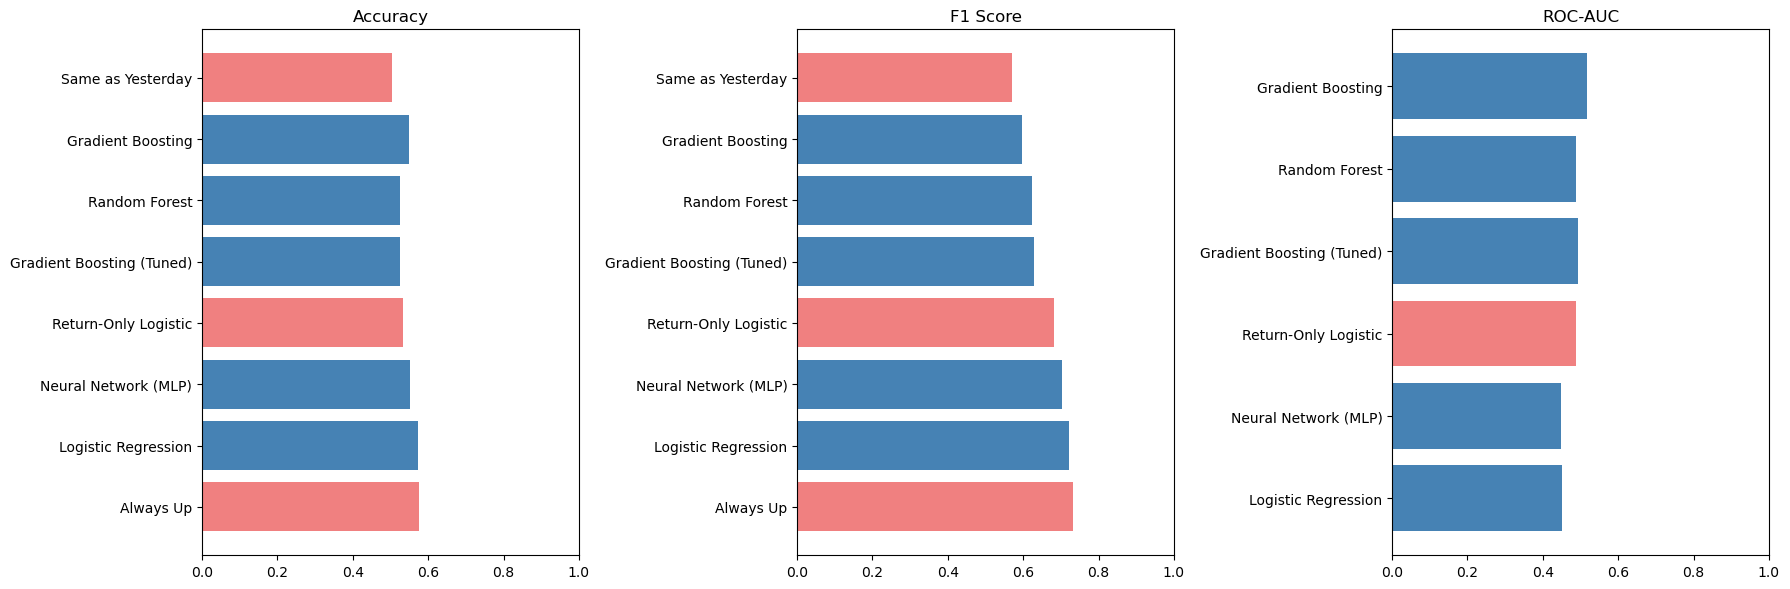

In [13]:
# comparison table sorted by F1
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('f1', ascending=False).reset_index(drop=True)

# round for readability
display_df = results_df.copy()
for col in ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}" if x is not None else "N/A")
print("All models ranked by F1 score:\n")
print(display_df.to_string(index=False))

# bar chart — baselines vs real models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_to_plot = ['accuracy', 'f1', 'roc_auc']
titles = ['Accuracy', 'F1 Score', 'ROC-AUC']

baseline_names = {'Always Up', 'Same as Yesterday', 'Return-Only Logistic'}

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    plot_df = results_df.dropna(subset=[metric]).copy()
    colors = ['lightcoral' if n in baseline_names else 'steelblue' for n in plot_df['name']]
    ax.barh(plot_df['name'], plot_df[metric], color=colors)
    ax.set_title(title)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

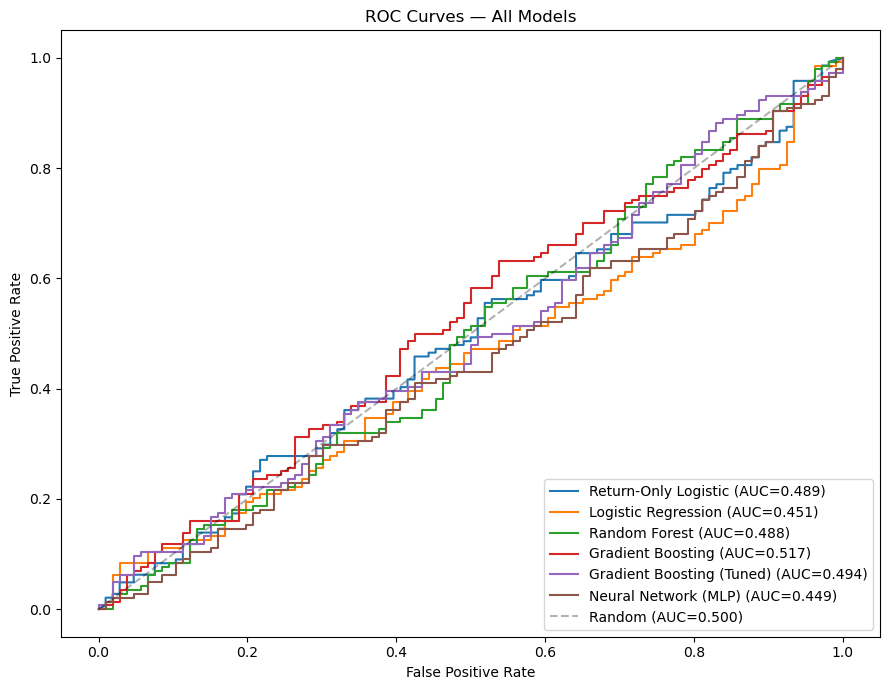

In [14]:
# ROC curves for all models that output probabilities
plt.figure(figsize=(9, 7))
for name, probs in prob_dict.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

=== Performance by VIX Regime ===
  High VIX (> 17.2):  Acc = 0.5840  (125 days)
  Low VIX  (<= 17.2): Acc = 0.4640  (125 days)

=== Performance by Market Trend ===
  Uptrend  (above SMA50):  Acc = 0.5027  (187 days)
  Downtrend (below SMA50): Acc = 0.5873  (63 days)

=== Performance by 20-day Volatility ===
  High Vol (> 0.00824): Acc = 0.5760  (125 days)
  Low Vol  (<= 0.00824): Acc = 0.4720  (125 days)


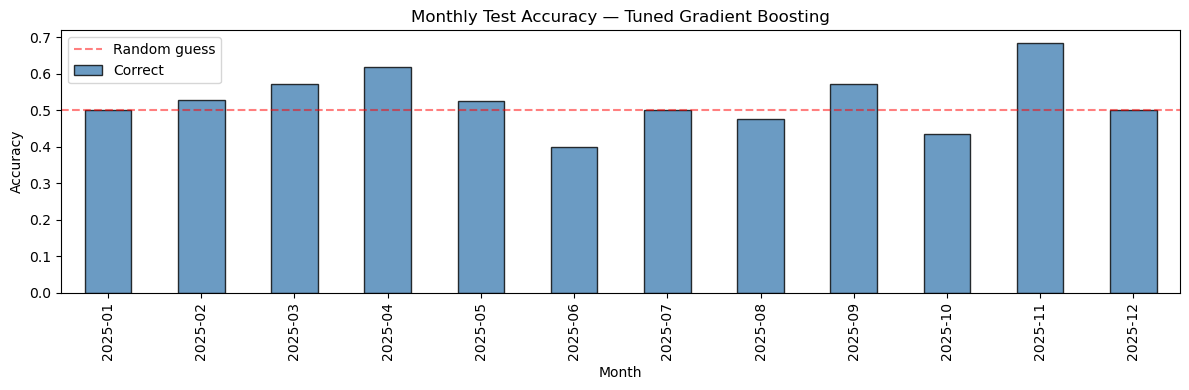

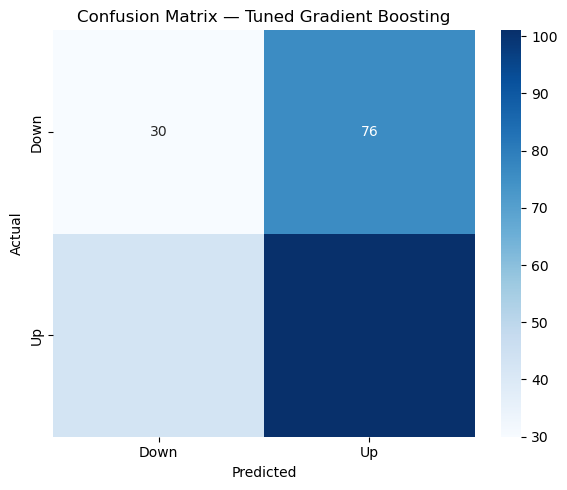

In [15]:
# we'll analyze the tuned gradient boosting since it's our best tree model
# (swap this out if the NN ends up doing better)
test_df = model_df.loc[test_mask].copy().reset_index(drop=True)
test_df['Predicted'] = y_pred_gb_tuned
test_df['Correct']   = (test_df['Target'] == test_df['Predicted']).astype(int)

# --- by VIX regime ---
vix_median = test_df['VIX_Close'].median()
high_vix = test_df[test_df['VIX_Close'] > vix_median]
low_vix  = test_df[test_df['VIX_Close'] <= vix_median]

print("=== Performance by VIX Regime ===")
print(f"  High VIX (> {vix_median:.1f}):  Acc = {high_vix['Correct'].mean():.4f}  ({len(high_vix)} days)")
print(f"  Low VIX  (<= {vix_median:.1f}): Acc = {low_vix['Correct'].mean():.4f}  ({len(low_vix)} days)")

# --- by market trend (above/below 50-day SMA) ---
uptrend   = test_df[test_df['Close_vs_SMA50'] > 0]
downtrend = test_df[test_df['Close_vs_SMA50'] <= 0]

print(f"\n=== Performance by Market Trend ===")
print(f"  Uptrend  (above SMA50):  Acc = {uptrend['Correct'].mean():.4f}  ({len(uptrend)} days)")
print(f"  Downtrend (below SMA50): Acc = {downtrend['Correct'].mean():.4f}  ({len(downtrend)} days)")

# --- by realized volatility ---
vol_median = test_df['Vol_20d'].median()
high_vol = test_df[test_df['Vol_20d'] > vol_median]
low_vol  = test_df[test_df['Vol_20d'] <= vol_median]

print(f"\n=== Performance by 20-day Volatility ===")
print(f"  High Vol (> {vol_median:.5f}): Acc = {high_vol['Correct'].mean():.4f}  ({len(high_vol)} days)")
print(f"  Low Vol  (<= {vol_median:.5f}): Acc = {low_vol['Correct'].mean():.4f}  ({len(low_vol)} days)")

# --- monthly accuracy over time ---
test_df['Month'] = test_df['Date'].dt.to_period('M')
monthly_acc = test_df.groupby('Month')['Correct'].mean()

plt.figure(figsize=(12, 4))
monthly_acc.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.8)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random guess')
plt.title('Monthly Test Accuracy — Tuned Gradient Boosting')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_gb_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Tuned Gradient Boosting')
plt.tight_layout()
plt.show()

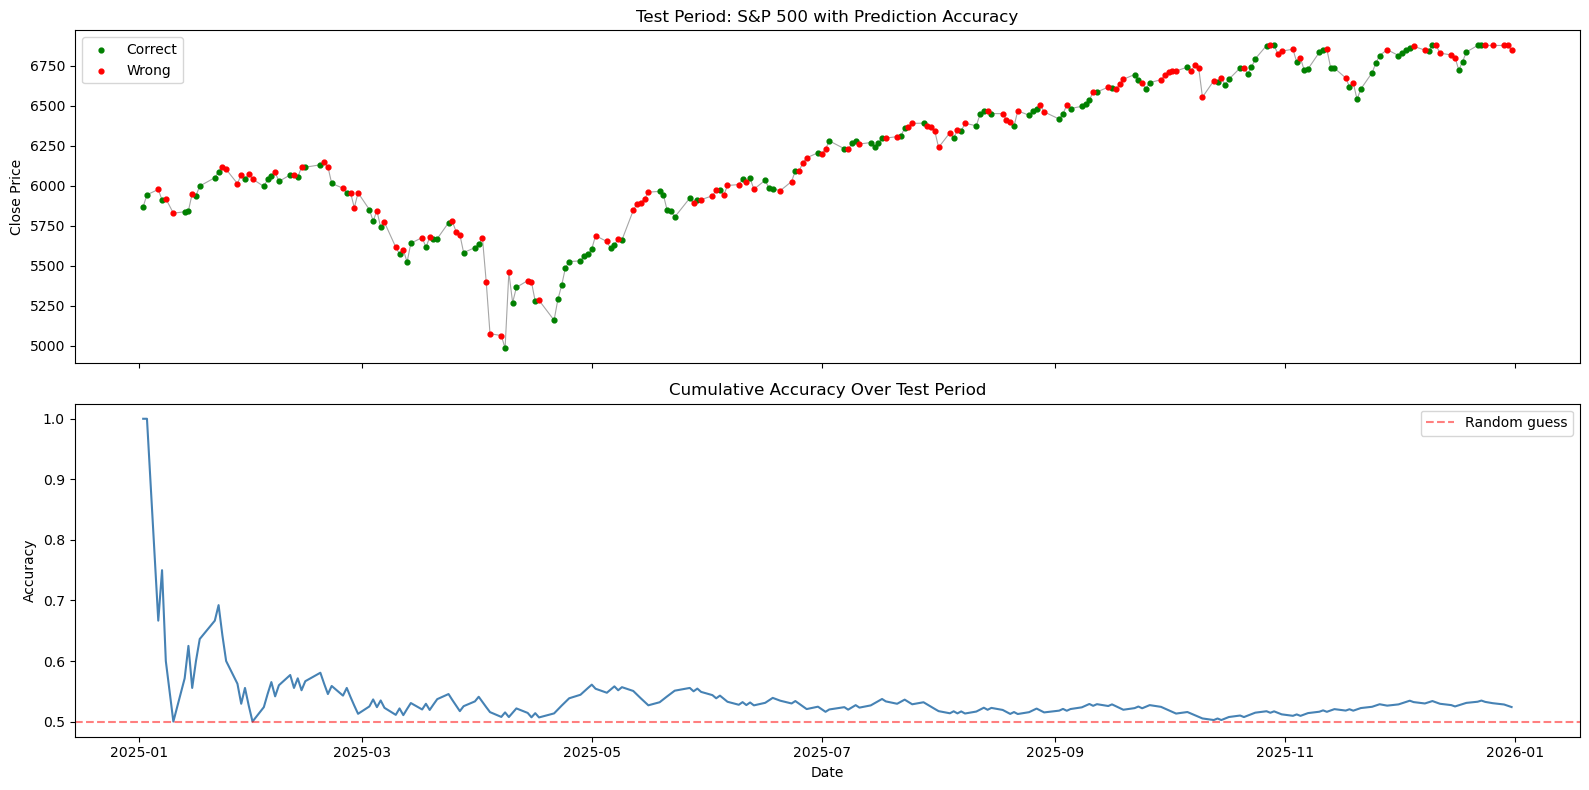

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

test_dates = test_df['Date']
test_close = test_df['Close']
correct_mask = test_df['Correct'] == 1
wrong_mask   = test_df['Correct'] == 0

# top: price with correct/wrong markers
ax1.plot(test_dates, test_close, color='gray', linewidth=0.8, alpha=0.7)
ax1.scatter(test_dates[correct_mask], test_close[correct_mask],
            c='green', s=12, label='Correct', zorder=3)
ax1.scatter(test_dates[wrong_mask], test_close[wrong_mask],
            c='red', s=12, label='Wrong', zorder=3)
ax1.set_title('Test Period: S&P 500 with Prediction Accuracy')
ax1.set_ylabel('Close Price')
ax1.legend()

# bottom: cumulative accuracy
cumulative_acc = test_df['Correct'].expanding().mean()
ax2.plot(test_dates, cumulative_acc, color='steelblue', linewidth=1.5)
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random guess')
ax2.set_title('Cumulative Accuracy Over Test Period')
ax2.set_ylabel('Accuracy')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.show()